<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Welcome to the Lensing challenge!

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

This hackathon is a chance to put your astronomy, statistics, and coding skills into practice, work together, and try out new ideas.

Your challenge is to estimate time delays from the supplied light curves. Explore the data, develop your method, and collect your predictions.

Start with a simple approach, compare ideas with your teammates, and build from there. 

&emsp;&emsp; Happy hacking!

</div>

In [78]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# Data

## The Generative Process

The data simulate **light curves** received from the [multiple] images of a lensed quasar — Just like in the animation below.

In [80]:
from IPython.display import Video, display
display(Video("videos/preprocessing.mp4", embed=False, width=800))

The data have been produced by **varying** the:
- **light source** (_flux, intrinsic variability, etc._)
- **lens** (_lens mass, microlensing effects_)
- **measurements effects** (_cadence of measurement, gaps_)

The purpose was to cover the **variety** of possible observations you may encounter in the field.

&emsp;&emsp; But, worry not!

You do not need to investigate the cause of such variety, in order to solve the exercise.

## Light Curves

Let us have a look at a couple of examples of the data you will receive.

Each source contains a light curve for **each image** of the quasar — There can be 2 (**double**) or 4 (**quad**) images, plus the central one.

In [ ]:
###### NEED AN IMAGE OF A QUAD AND A DOUBLE SIDE BY SIDE
###### NEED AN IMAGE OF A QUAD AND A DOUBLE SIDE BY SIDE
###### NEED AN IMAGE OF A QUAD AND A DOUBLE SIDE BY SIDE
###### NEED AN IMAGE OF A QUAD AND A DOUBLE SIDE BY SIDE
###### NEED AN IMAGE OF A QUAD AND A DOUBLE SIDE BY SIDE
###### NEED AN IMAGE OF A QUAD AND A DOUBLE SIDE BY SIDE

The central image that falls on top of the lensing galaxy is tipically so demagnified that it is basically
<u>never</u> observed in reality $\rightarrow$ We will **ignore** that one curve.

There are therefore 3 (**double** image) or 5 (**quad** image) entries in each file, but we only care for 2 (or 4).

In [124]:
LC_FILE = "mock_data/testCAM-i_LC_sampled 99.json"

def load_lc_file(path_to_file):
    """Load light curves from a JSON file into a dictionary of DataFrames.

    Parameters
    ----------
    path_to_file : str or path-like
        Path to a JSON file containing a list of light-curve dictionaries.
        Each dictionary contains equal-length arrays: ``time`` (days),
        ``signal`` (magnitudes), and ``dsignal`` (signal uncertainties).

    Returns
    -------
    dict[int, pandas.DataFrame]
        Light curves indexed by their zero-based position in the file.
        Each DataFrame has one row per observation and preserves the
        original column names and values.
    """
    with open(path_to_file, encoding="utf-8") as fh:
        curves = json.load(fh)

    df_curves = {}
    for i, curve in enumerate(curves):
        df_curves[i] = pd.DataFrame(curve)

    return df_curves

curves_dict = load_lc_file(LC_FILE)

for i, df_curve in curves_dict.items():
    display(df_curve.head(3))

,dsignal,signal,time
0,22.200953,23.934294,1200.00
1,22.200950,23.931005,1206.99
2,22.200946,23.962836,1214.01


,dsignal,signal,time
0,22.193681,24.083736,1200.00
1,22.193687,24.083193,1206.99
2,22.193693,24.077385,1214.01


,dsignal,signal,time
0,22.19,34.966851,1200.00
1,22.19,34.964448,1206.99
2,22.19,34.987801,1214.01


,dsignal,signal,time
0,22.194173,22.645370,1200.00
1,22.194171,22.658768,1206.99
2,22.194169,22.640693,1214.01


,dsignal,signal,time
0,22.192514,22.224430,1200.00
1,22.192518,22.211898,1206.99
2,22.192522,22.240952,1214.01


**Units**
- time $-$ days
- signal $-$ magnitude
- dsignal $-$ mag error

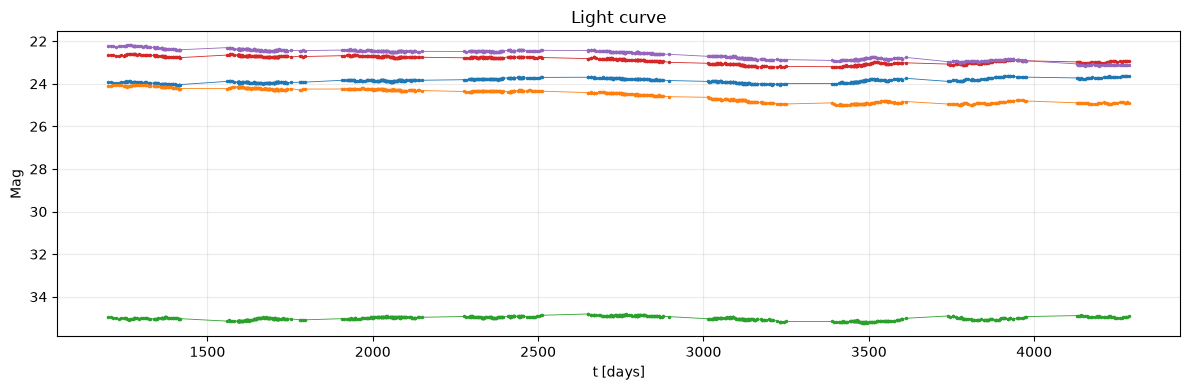

In [126]:
fig, ax = plt.subplots(figsize=(12, 4))
for i, df_curve in curves_dict.items():
    ax.plot(df_curve["time"], df_curve["signal"], ".-", ms=3, lw=0.6)
    ax.invert_yaxis()
    ax.grid(alpha=0.25)
    ax.set(xlabel="t [days]", ylabel="Mag", title="Light curve")
plt.tight_layout()
plt.show()


The central image that falls on top of the lensing galaxy is tipically so demagnified that it is basically
<u>never</u> observed in reality $\rightarrow$ We will **ignore** that one curve.

There are therefore 3 (**double** image) or 5 (**quad** image) entries in each file, but we only care for 2 (or 4).

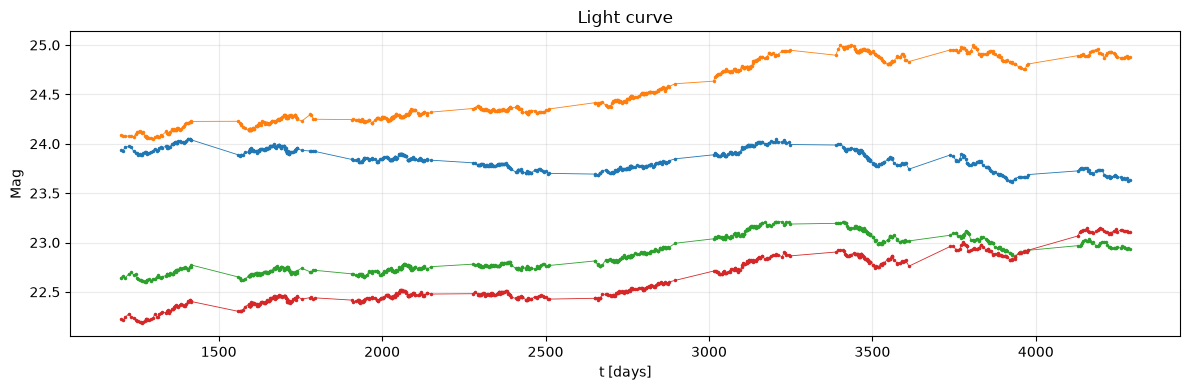

In [135]:
fig, ax = plt.subplots(figsize=(12, 4))
for i, df_curve in curves_dict.items():
    if i==2: continue  # skipping central image
    ax.plot(df_curve["time"], df_curve["signal"], ".-", ms=3, lw=0.6)
    ax.invert_yaxis()
    ax.grid(alpha=0.25)
    ax.set(xlabel="t [days]", ylabel="Mag", title="Light curve")
plt.tight_layout()
plt.show()


# Methods

# Metric

In [72]:
# You do not own this
df_truth = pd.DataFrame(columns=["ID", "dt_01_days", "dt_02_days", "dt_03_days"])

df_truth.loc[len(df_truth)] = ["AAA", 0.11, "NA", "NA"]  # double system
df_truth.loc[len(df_truth)] = ["BBB", 0.13, 0.19, 0.31]  # quad system
df_truth.loc[len(df_truth)] = ["CCC", 0.13, 0.19, 0.31]  # malfomed line (ID does not exists), will be skipped by the scorer

display(df_truth)


,ID,dt_01_days,dt_02_days,dt_03_days
0,AAA,0.11,NA,NA
1,BBB,0.13,0.19,0.31
2,CCC,0.13,0.19,0.31


In [73]:
# You submit this
df_results = pd.DataFrame(columns=["ID", "dt_01_days", "dt_02_days", "dt_03_days"])

df_results.loc[len(df_results)] = ["AAA", 0.10, "NA", "NA"]   # double system
df_results.loc[len(df_results)] = ["BBB", 0.11, 0.22, 0.33]  # You do not own this# quad system

display(df_results)


,ID,dt_01_days,dt_02_days,dt_03_days
0,AAA,0.10,NA,NA
1,BBB,0.11,0.22,0.33


In [76]:
def score(df_results, df_truth):
    """Return the root mean squared error (RMSE) in days.
    
    Compute the square root of the average squared error across all matched
    IDs and all three time-delay columns. Skip pairs where either value is
    missing ("NA", "NaN", or np.nan). Return NaN if no valid pairs remain.

    Parameters
    ----------
    df_results, df_truth : pandas.DataFrame
        Predicted and reference values, respectively. Each must contain
        ``ID``, ``dt_01_days``, ``dt_02_days``, and ``dt_03_days``.
        Only IDs present in both frames are scored (inner join).

    Returns
    -------
    float
        Square root of the mean squared difference across all valid delay
        pairs, with equal weight per pair. Lower is better; zero is exact.
        Returns NaN if no valid pairs remain.

    Notes
    -----
    Numeric strings are accepted. Missing values (including the strings
    "NA" and "NaN", and np.nan) and other nonnumeric values are coerced
    to NaN. A pair is excluded if either value is missing.
    Displays the first five comparison rows with signed errors.
    """
    
    df_comparison = df_truth.merge(
        df_results, on="ID", suffixes=("_truth", "_result")
    )
    
    for col in ["dt_01_days", "dt_02_days", "dt_03_days"]:
        truth  = pd.to_numeric(df_comparison[f"{col}_truth"],  errors="coerce")
        result = pd.to_numeric(df_comparison[f"{col}_result"], errors="coerce")
        df_comparison[f"{col}_error"] = result - truth
    
    display(df_comparison.head())
    
    # Pool all valid errors before taking the root mean square.
    errors = df_comparison[[f"{col}_error" for col in [
        "dt_01_days", "dt_02_days", "dt_03_days"
    ]]].stack()
    rmse = float(np.sqrt(errors.pow(2).mean()))
    
    return rmse

print("You score: %.2g" % score(df_results, df_truth))

,ID,dt_01_days_truth,dt_02_days_truth,dt_03_days_truth,dt_01_days_result,dt_02_days_result,dt_03_days_result,dt_01_days_error,dt_02_days_error,dt_03_days_error
0,AAA,0.11,NA,NA,0.10,NA,NA,-0.01,NaN,NaN
1,BBB,0.13,0.19,0.31,0.11,0.22,0.33,-0.02,0.03,0.02


You score: 0.021


In [ ]:
#EOF